# Detectar Anomalias

- FILE1AA_MODIFICADO: humedad, master speed, nivel banda tolva, flujo aceite, temp salida intercambiador, deltaTpid
- FILEJUNIO:          humedad, master speed, nivel aceite actual PID, nivel aceite actual, flujo aceite. deltaTpid
- FILEJULIO:          same filejunio
- FILE1JULIO:         same filejunio
- FILE1A3:            humedad, master spped, nivel aceite actual, deltaTPID


## 1. FILEJUNIO

- FILEJUNIO:          humedad, master speed, nivel aceite actual PID, nivel aceite actual, flujo aceite. deltaTpid


### Isolation Forest

 Funciona construyendo múltiples árboles de aislamiento (Isolation Trees) y utilizando la profundidad de estos árboles para determinar si un punto de datos es una anomalía.


 La profundidad de un punto de datos en un árbol de aislamiento es el número de divisiones necesarias para aislar ese punto.


Los puntos de datos que son anomalías tienden a ser aislados más rápidamente (en menos divisiones) porque están en regiones escasamente pobladas del espacio de características.

La puntuación de anomalía de un punto de datos se calcula como la media de las profundidades de ese punto en todos los árboles de aislamiento.
Esta puntuación se normaliza para que esté en el rango [0, 1], donde los valores más cercanos a 1 indican una mayor probabilidad de ser una anomalía.

**Contamination:** proporción datos que es anomalia. Por defecto es 0.1. Pero si se sabe historicamente de la data que se tiene que la proporción de anomalias es mayor, se puede cambiar este valor.

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

df.shape
# Seleccionar las columnas relevantes para el modelo
features = ['Pc_OIT_24Real[000]', 'Pc_OIT_24Real[004]', 'DeltaTPid.Pid_SP', 'Pc_OIT_24Real[001]Pid.Pid_SP', 'Pc_OIT_24Real[001]', 'FT1501.Value']
X = df[features]

# Calcular el valor común general (mediana) para cada feature
medians = X.median()

# Aplicar Isolation Forest
model = IsolationForest(contamination='auto', random_state=42) # o de 0.01 a 0.5
df['anomaly'] = model.fit_predict(X)

# Mostrar la cantidad de filas con anomalías
num_anomalies = df[df['anomaly'] == -1].shape[0]
print(f'Cantidad de filas con anomalías: {num_anomalies}')


C:\Users\josef\AppData\Local\Temp\ipykernel_2260\2868303712.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Cantidad de filas con anomalías: 5742


In [23]:
# Mostrar las anomalías y los valores anómalos
anomalies = df[df['anomaly'] == -1]
#print('Filas con anomalías:')
#print(anomalies)

print('Valores comunes generales (medianas) por cada feature:')
print(medians)
print('-------------------------------------------------------')
print('Anomalías detectadas:')
for index, row in anomalies.iterrows():
    print(f'Fila {index}:')
    for feature in features:
        if row[feature] != medians[feature]:
            print(f'  {feature}: {row[feature]}')
print('-------------------------------------------------------')



Valores comunes generales (medianas) por cada feature:
Pc_OIT_24Real[000]                 1.328551
Pc_OIT_24Real[004]                78.000000
DeltaTPid.Pid_SP                  10.988420
Pc_OIT_24Real[001]Pid.Pid_SP     215.000000
Pc_OIT_24Real[001]               211.476700
FT1501.Value                    3016.489000
dtype: float64
-------------------------------------------------------
Anomalías detectadas:
Fila 405:
  Pc_OIT_24Real[000]: 0.6879631
  Pc_OIT_24Real[004]: 90.0
  DeltaTPid.Pid_SP: 2.629064
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 210.3774
  FT1501.Value: 3047.622
Fila 779:
  Pc_OIT_24Real[000]: 1.112357
  Pc_OIT_24Real[004]: 100.0
  DeltaTPid.Pid_SP: 11.38204
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 208.0058
  FT1501.Value: 3034.912
Fila 1144:
  Pc_OIT_24Real[000]: 0.7599382
  Pc_OIT_24Real[004]: 111.0
  DeltaTPid.Pid_SP: 2.136316
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 205.5733
  FT1501.Value: 3019.987
Fila 1185:

Estos gráficos te ayudarán a identificar patrones y posibles anomalías en tus datos.



- Grafico de dispersion: relacin entre cada par de caracteristicas en los datos. Puntos alejados del resto de los datos, son puntos qque pueden ser considerados como anomalias.
- Histogramas: distribucion de cada caracteristica en los datos.Barras alejadas del resto de la distribucion, pueden indicar valores atipicos. Eje X, valores de la caracteristica. Eje Y, frecuencia de observaciones que caen dentro de cada intervalo del eje X. 
- Boxplot: distribucion de cada caracteristica en los datos. Puntos fuera de los bigotes, pueden ser considerados anomalia. 


C:\Users\josef\AppData\Local\Temp\ipykernel_2260\3571696133.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


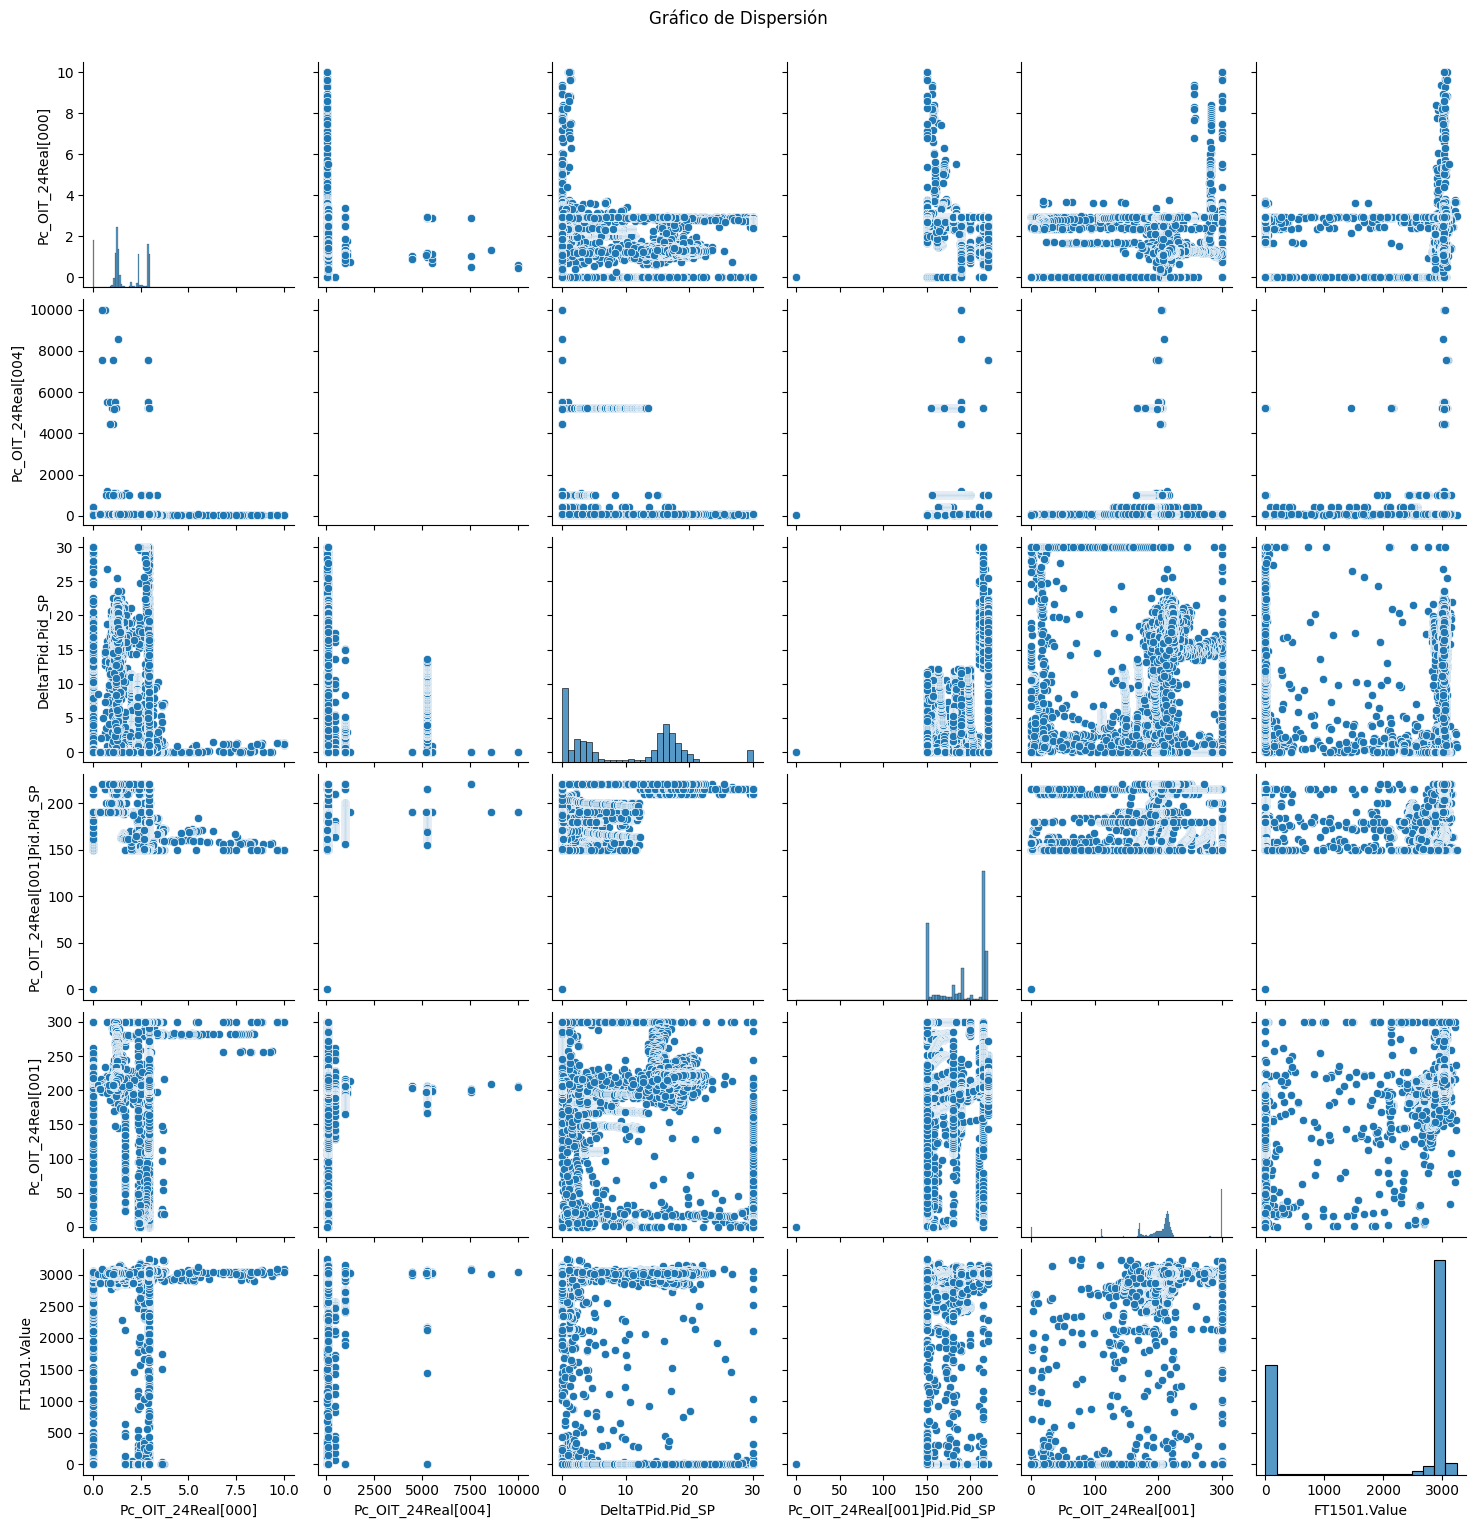

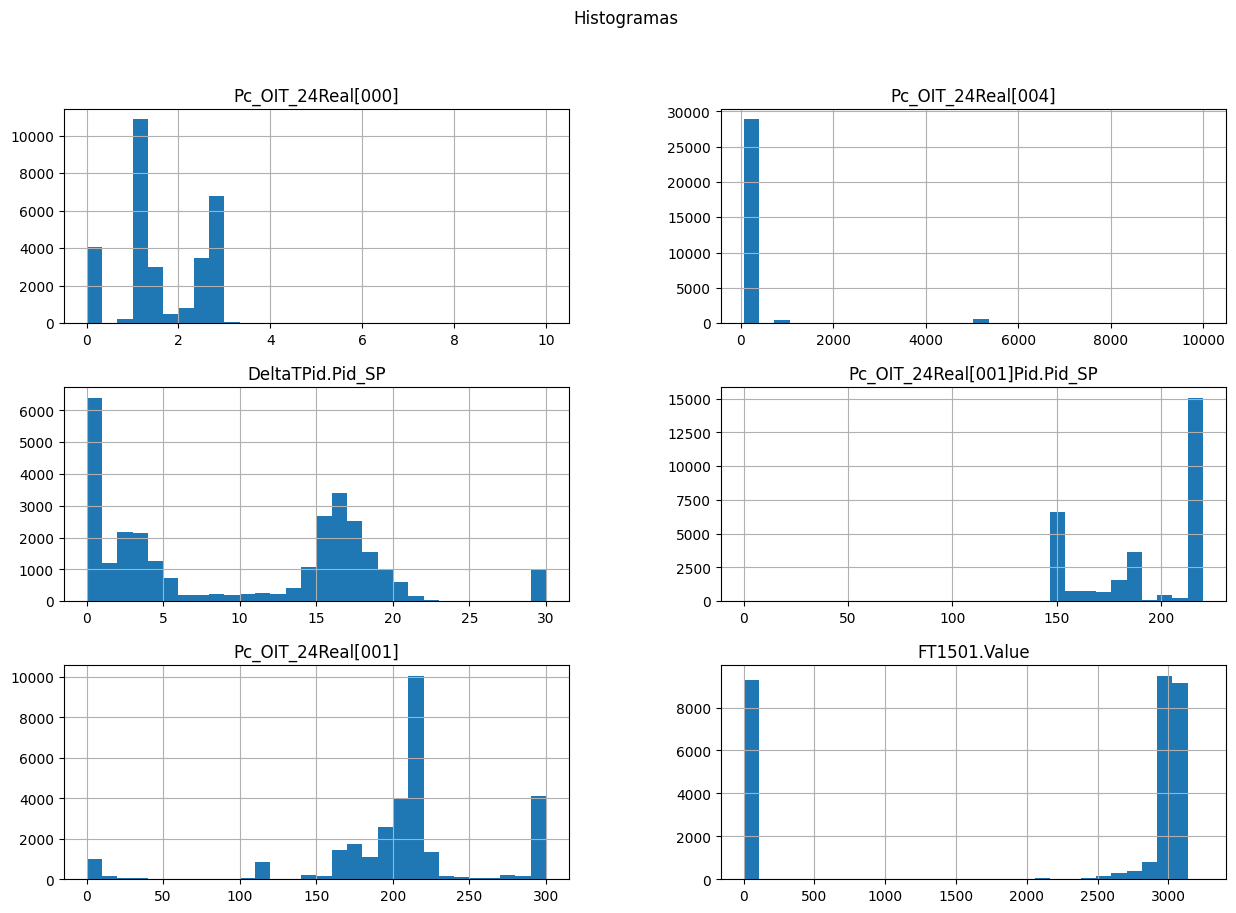

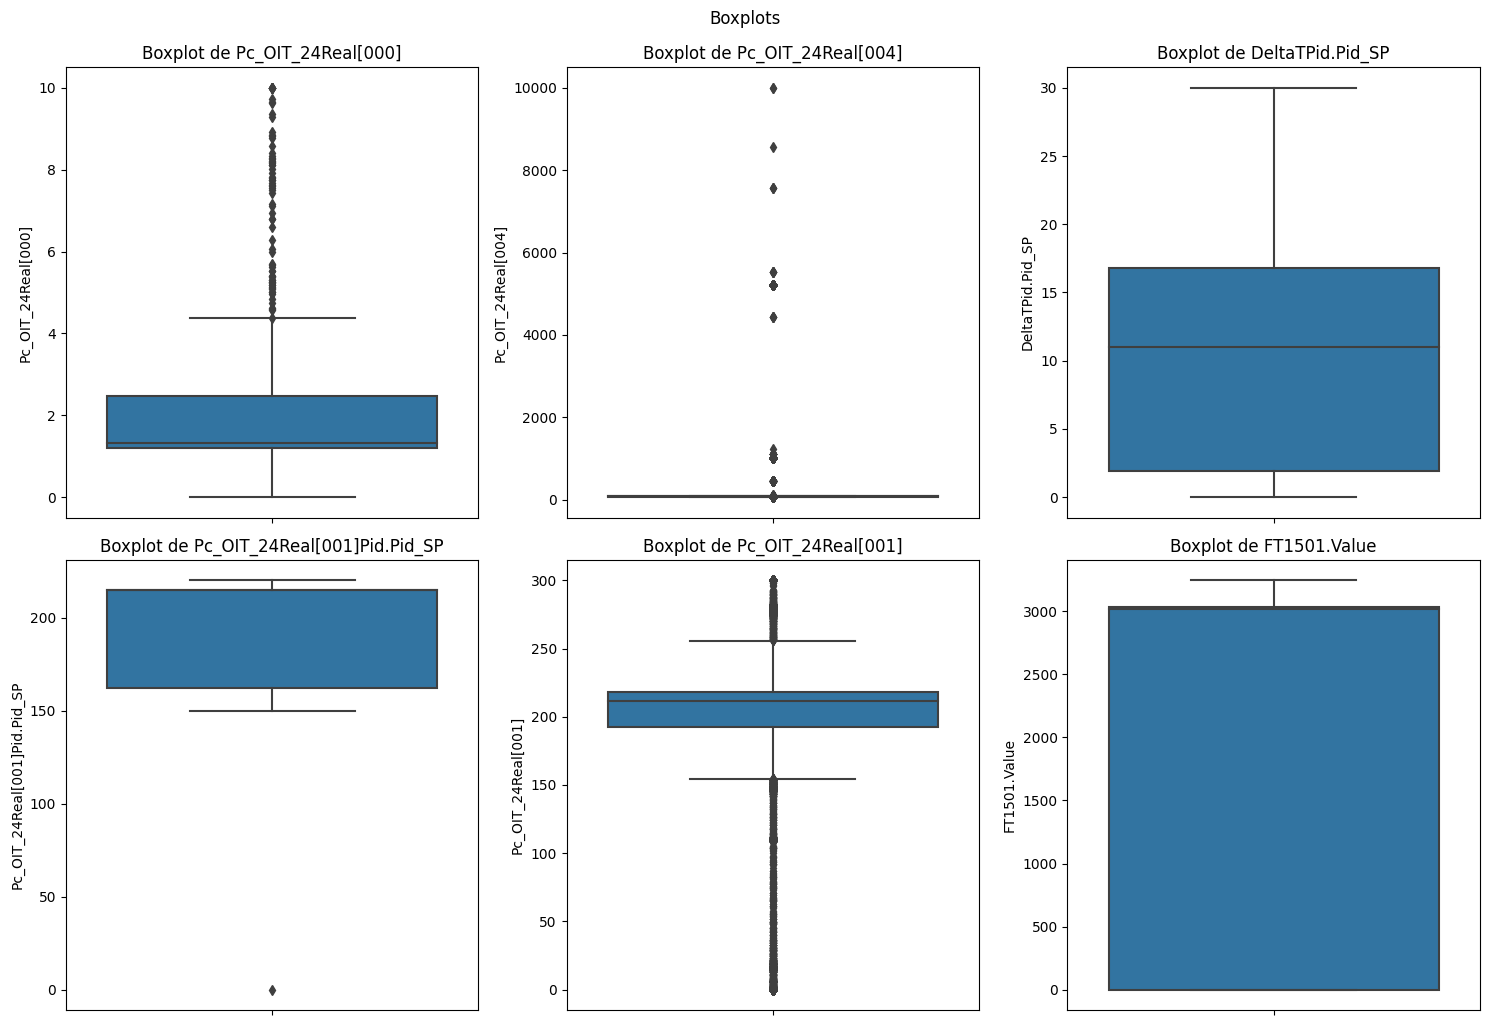

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar las columnas relevantes para el análisis
features = ['Pc_OIT_24Real[000]', 'Pc_OIT_24Real[004]', 'DeltaTPid.Pid_SP', 'Pc_OIT_24Real[001]Pid.Pid_SP', 'Pc_OIT_24Real[001]', 'FT1501.Value']

# Gráfico de dispersión
sns.pairplot(df[features])
plt.suptitle('Gráfico de Dispersión', y=1.02)
plt.show()

# Histogramas
df[features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histogramas')
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.suptitle('Boxplots', y=1.02)
plt.show()

### ARIMA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf


#### Diferencias de tiempo

In [2]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Calcular las diferencias de tiempo entre las observaciones consecutivas
time_diffs = df['Datetime'].diff().dropna()

# Mostrar las diferencias de tiempo
print(time_diffs.describe())

C:\Users\josef\AppData\Local\Temp\ipykernel_492\968400231.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


count              43200
mean     0 days 00:01:00
std      0 days 00:00:00
min      0 days 00:01:00
25%      0 days 00:01:00
50%      0 days 00:01:00
75%      0 days 00:01:00
max      0 days 00:01:00
Name: Datetime, dtype: object


Intervalo de tiempo entre las observaciones es de 1 minuto

#### Codigo de modelo

##### a. Pc_OIT_24Real[004]: Velocidad Maestra Freidor

Probando si es estacionario o no
- Si lo es d=0
- Si no lo es d=1 o +

In [3]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal: secuencia de datos, en mediciones sucesivas hechas a intervalos de tiempo.
series = df.set_index('Datetime')['Pc_OIT_24Real[004]']

# Verificar si la serie es estacionaria: si la media y la varianza (propiedades estadisticas) son constantes en el tiempo. Una serie estacionaria no tiene tendencias ni estacionalidades que cambien con el tiempo.
result = adfuller(series)
print('ADF Statistic:', result[0]) # Prueba Dickey Fuller aumentada: verifica si una serie temporal es o no estacionaria
print('p-value:', result[1]) # Si es menor que 0.05, la serie temporal es estacionaria, y a reves

# Si la serie no es estacionaria (p-value > 0.05), diferenciarla
#verifica si serie temporal es estacionaria y sino lo es se aplica una trsnformacion para hacerla estacionaria
# pues arima funciona con suposicion que sus series son estacionarias
if result[1] > 0.05:
    series = series.diff().dropna() #calcula la diferencia entre un valor y el anterior y elimina los valores nulos de la diferenciacion


C:\Users\josef\AppData\Local\Temp\ipykernel_492\1501571739.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


ADF Statistic: -8.092590163695311
p-value: 1.3656075333451635e-12


Ver valores de p y q
- Con graficos ACF y PACF
- ACF: muestra correlacion entre la serie y sus retardos
- PACF: muestra correlacion entre la serie y sus retardos, eliminado la influencia de los retardos intermedios. 

- Eje X: lags (retardos) en la serie temporal.
- Eje Y: autocorrelacion entre los valores de la serie temporal, entre -1 y 1.

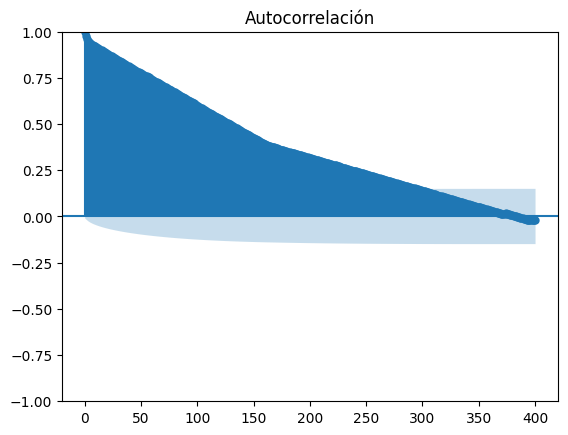

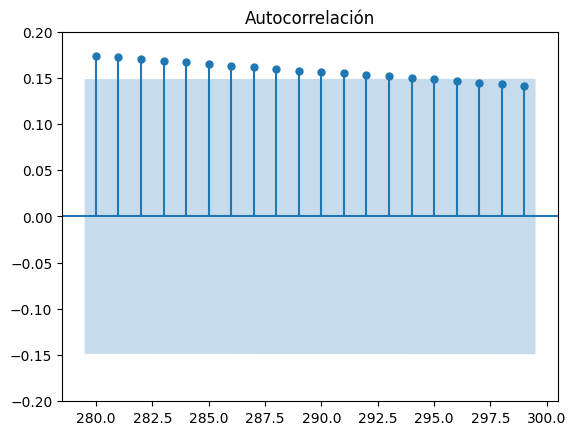

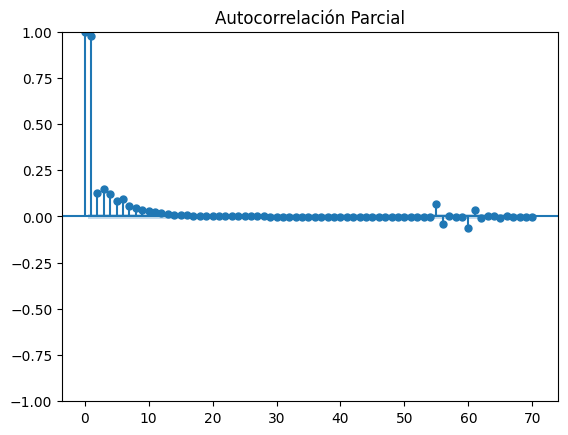

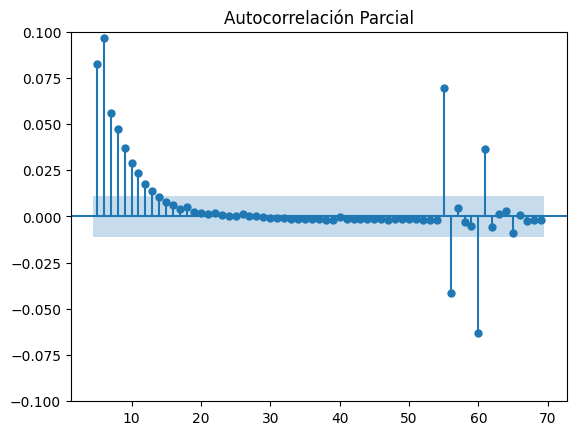

In [4]:
# Gráfico de autocorrelación
plot_acf(series, lags=400)
plt.title('Autocorrelación')
plt.show()
# Gráfico de autocorrelación
plot_acf(series, lags=range(280,300))
plt.title('Autocorrelación')
plt.ylim(-0.2,0.2)
plt.show()

# Gráfico de autocorrelación parcial
plot_pacf(series, lags=70)
plt.title('Autocorrelación Parcial')
plt.show()
# Gráfico de autocorrelación parcial
plot_pacf(series, lags=range(5,70))
plt.title('Autocorrelación Parcial')
plt.ylim(-0.1,0.1)
plt.show()

- p=91
- d=0
- q=13

predeterminado antes era (5,1,0)

Por ahora pongo 5,0,0. Porque estuve 210 min corrieno el modelo y no termino.

c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Cantidad de anomalías detectadas: 70
Anomalías detectadas:
Datetime
2016-06-02 18:02:00    9923.361345
2016-06-02 18:03:00    1935.610269
2016-06-02 18:04:00   -7935.390532
2016-06-02 18:06:00   -1032.013836
2016-06-02 18:07:00   -1352.139320
                          ...     
2016-06-27 13:39:00   -1395.507754
2016-06-27 13:40:00   -1019.372745
2016-06-27 13:41:00    -618.868640
2016-07-01 07:32:00     922.375373
2016-07-01 07:57:00    -911.662481
Length: 70, dtype: float64


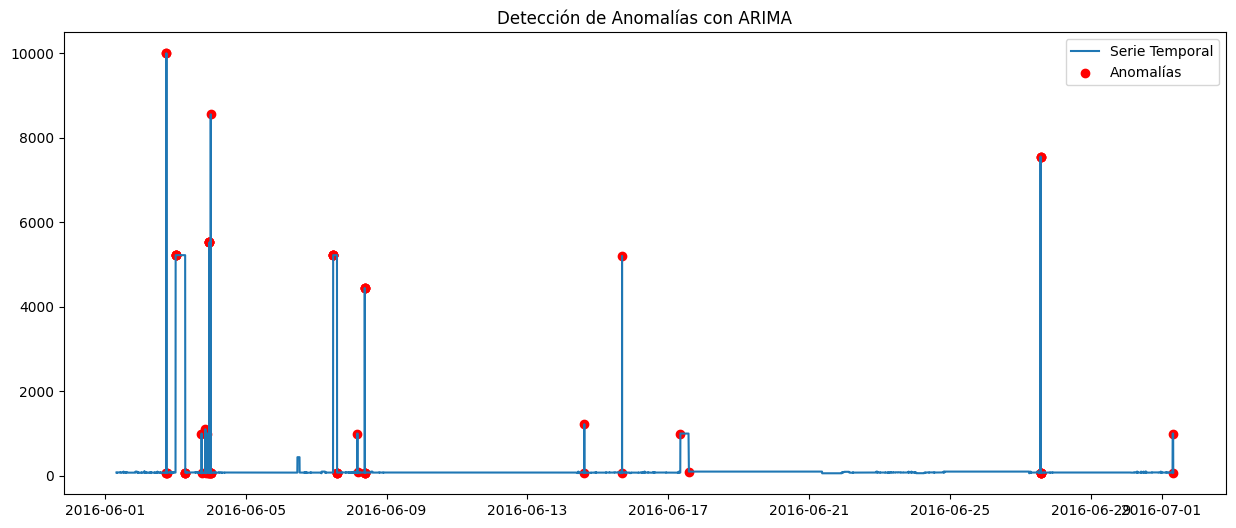

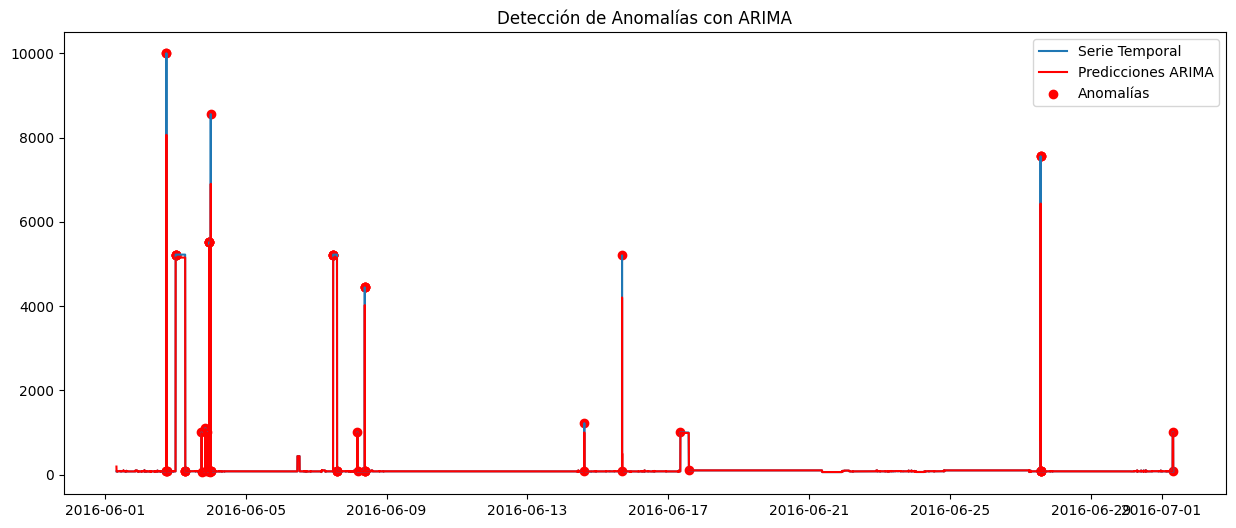

In [6]:
# Ajustar el modelo ARIMA
model = ARIMA(series, order=(5, 0, 0))  # (p, d, q) 
#model = ARIMA(series, order=(91, 0, 13))  # (p, d, q) 
# p: número de términos autorregresivos, numero de observaciones pasadas del modelo
# d: número de diferencias no estacionales para hacer la serie temporal estacionaria
#       0= si serie es estacionaria
#       1O+= si serie no es estacionaria
# q: número de términos de media móvil, numero de errores pasados que se deben corregir
model_fit = model.fit()

# Realizar predicciones
predictions = model_fit.predict(start=0, end=len(series)-1, dynamic=False)

# Calcular los residuos (errores)
residuals = series - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3* np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
#plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

##### b. Pc_OIT_24Real[001]: Nivel Aceite Actual

Probando si es estacionario o no
- Si lo es d=0
- Si no lo es d=1 o +

In [7]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal: secuencia de datos, en mediciones sucesivas hechas a intervalos de tiempo.
series = df.set_index('Datetime')['Pc_OIT_24Real[001]']

# Verificar si la serie es estacionaria: si la media y la varianza (propiedades estadisticas) son constantes en el tiempo. Una serie estacionaria no tiene tendencias ni estacionalidades que cambien con el tiempo.
result = adfuller(series)
print('ADF Statistic:', result[0]) # Prueba Dickey Fuller aumentada: verifica si una serie temporal es o no estacionaria
print('p-value:', result[1]) # Si es menor que 0.05, la serie temporal es estacionaria, y a reves

# Si la serie no es estacionaria (p-value > 0.05), diferenciarla
#verifica si serie temporal es estacionaria y sino lo es se aplica una trsnformacion para hacerla estacionaria
# pues arima funciona con suposicion que sus series son estacionarias
if result[1] > 0.05:
    series = series.diff().dropna() #calcula la diferencia entre un valor y el anterior y elimina los valores nulos de la diferenciacion


C:\Users\josef\AppData\Local\Temp\ipykernel_492\187304061.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


ADF Statistic: -7.050358225489971
p-value: 5.547008394277374e-10


Ver valores de p y q
- Con graficos ACF y PACF
- ACF: muestra correlacion entre la serie y sus retardos
- PACF: muestra correlacion entre la serie y sus retardos, eliminado la influencia de los retardos intermedios. 

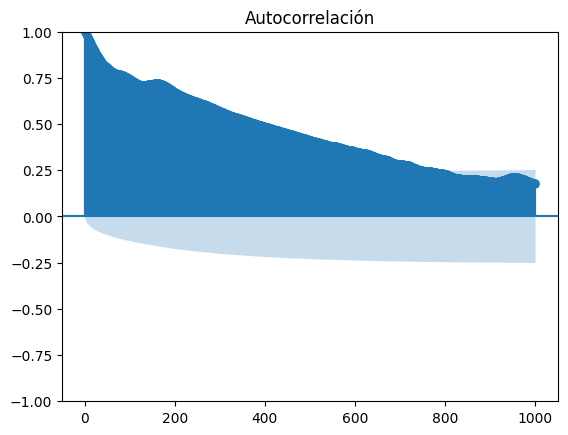

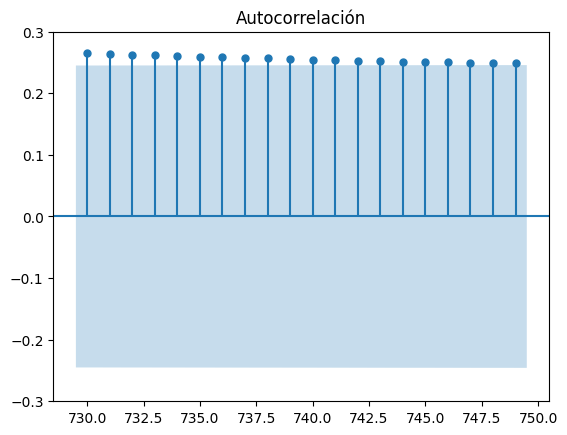

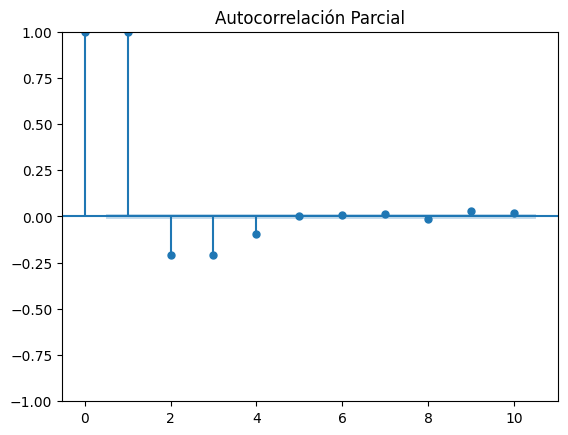

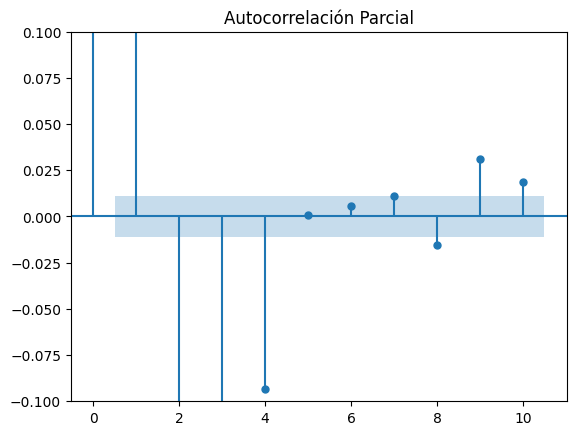

In [14]:
# Gráfico de autocorrelación
plot_acf(series, lags=1000)
plt.title('Autocorrelación')
plt.show()
# Gráfico de autocorrelación
plot_acf(series, lags=range(730,750))
plt.title('Autocorrelación')
plt.ylim(-0.3,0.3)
plt.show()

# Gráfico de autocorrelación parcial
plot_pacf(series, lags=10)
plt.title('Autocorrelación Parcial')
plt.show()
# Gráfico de autocorrelación parcial
plot_pacf(series, lags=10)
plt.title('Autocorrelación Parcial')
plt.ylim(-0.1,0.1)
plt.show()

- p= 741
- d= 0
- q= 4


c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Cantidad de anomalías detectadas: 329
Anomalías detectadas:
Datetime
2016-06-01 23:14:00    12.359745
2016-06-01 23:25:00    11.244953
2016-06-02 03:40:00   -12.593347
2016-06-02 03:58:00   -13.788924
2016-06-02 05:32:00   -11.407726
                         ...    
2016-06-27 23:04:00   -11.425257
2016-06-27 23:39:00    16.584622
2016-06-27 23:40:00   -18.920484
2016-06-27 23:56:00    17.573737
2016-06-30 00:00:00    25.625101
Length: 329, dtype: float64


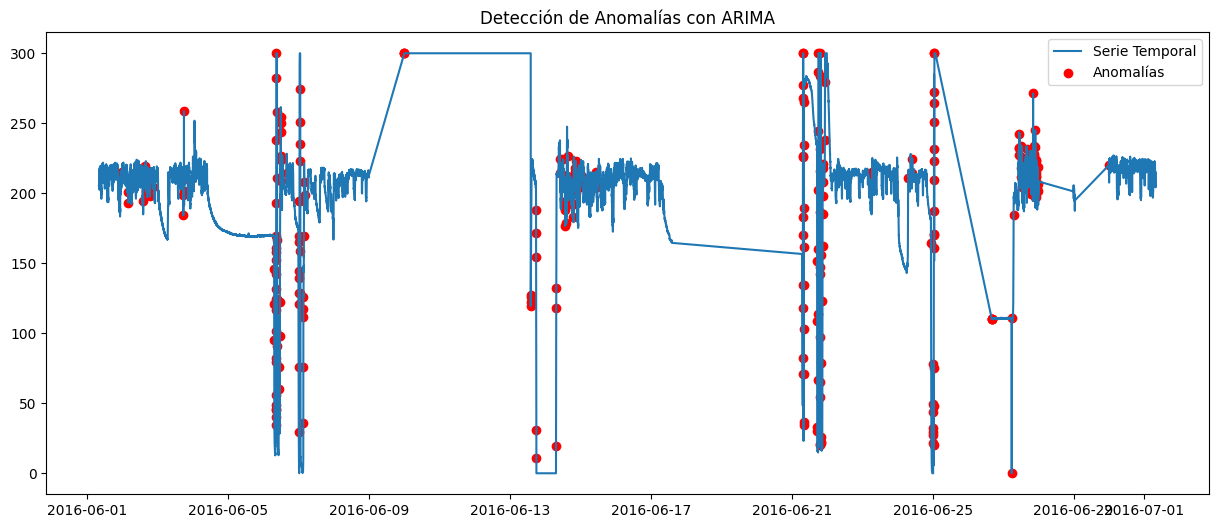

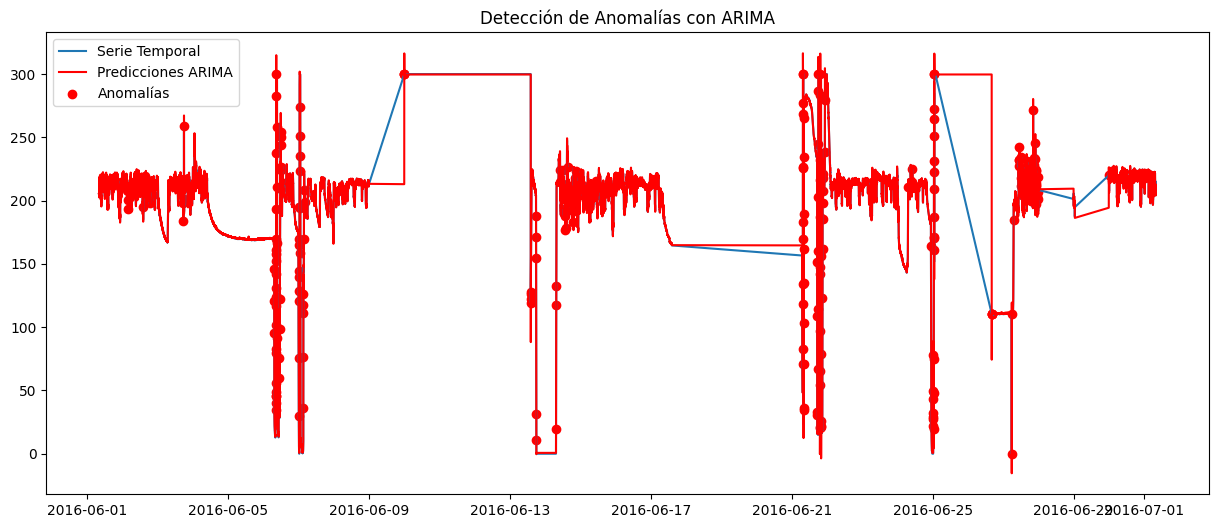

In [ ]:
# Ajustar el modelo ARIMA
model = ARIMA(series, order=(5, 0, 0))  # (p, d, q) 
#model = ARIMA(series, order=(741, 0, 4))  # (p, d, q) 

# p: número de términos autorregresivos, numero de observaciones pasadas del modelo
# d: número de diferencias no estacionales para hacer la serie temporal estacionaria
# q: número de términos de media móvil, numero de errores pasados que se deben corregir
model_fit = model.fit()

# Realizar predicciones
predictions = model_fit.predict(start=0, end=len(series)-1, dynamic=False)

# Calcular los residuos (errores)
residuals = series - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3* np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
#plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

##### c. FT1501.Value: Sensor Flujo Actual Aceite

Probando si es estacionario o no
- Si lo es d=0
- Si no lo es d=1 o +

In [17]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal: secuencia de datos, en mediciones sucesivas hechas a intervalos de tiempo.
series = df.set_index('Datetime')['FT1501.Value']

# Verificar si la serie es estacionaria: si la media y la varianza (propiedades estadisticas) son constantes en el tiempo. Una serie estacionaria no tiene tendencias ni estacionalidades que cambien con el tiempo.
result = adfuller(series)
print('ADF Statistic:', result[0]) # Prueba Dickey Fuller aumentada: verifica si una serie temporal es o no estacionaria
print('p-value:', result[1]) # Si es menor que 0.05, la serie temporal es estacionaria, y a reves

# Si la serie no es estacionaria (p-value > 0.05), diferenciarla
#verifica si serie temporal es estacionaria y sino lo es se aplica una trsnformacion para hacerla estacionaria
# pues arima funciona con suposicion que sus series son estacionarias
if result[1] > 0.05:
    series = series.diff().dropna() #calcula la diferencia entre un valor y el anterior y elimina los valores nulos de la diferenciacion


C:\Users\josef\AppData\Local\Temp\ipykernel_492\906584375.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


ADF Statistic: -4.847559027373676
p-value: 4.406818941734173e-05


Ver valores de p y q
- Con graficos ACF y PACF
- ACF: muestra correlacion entre la serie y sus retardos
- PACF: muestra correlacion entre la serie y sus retardos, eliminado la influencia de los retardos intermedios. 

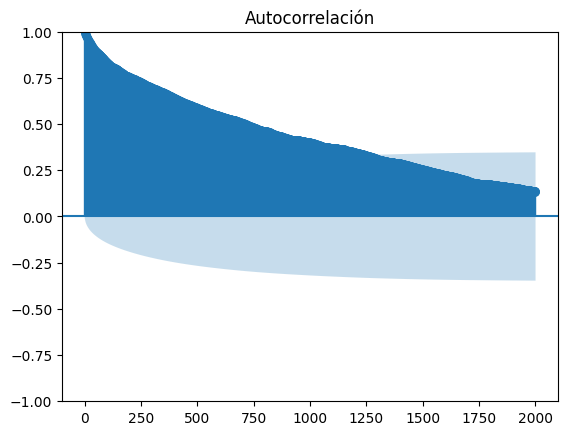

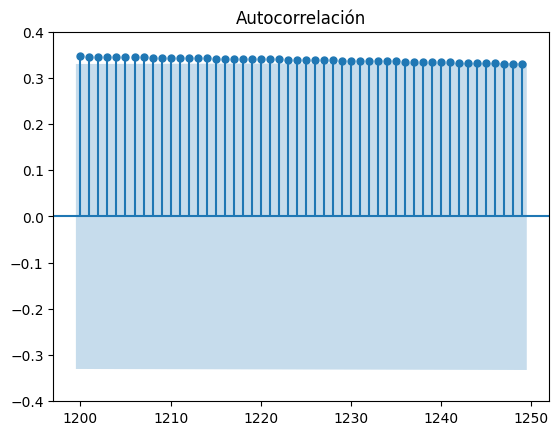

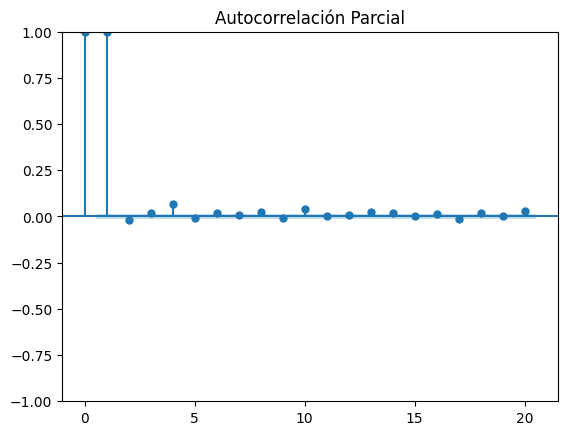

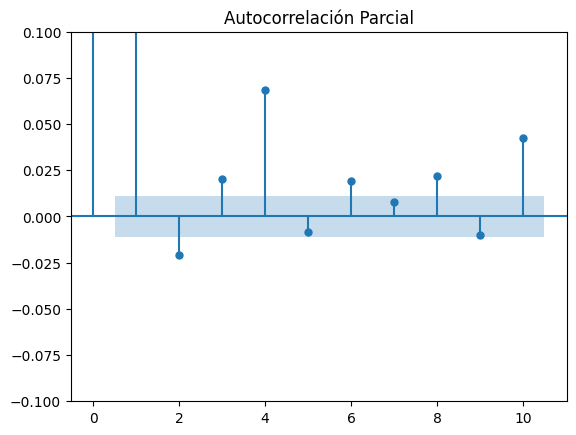

In [28]:
# Gráfico de autocorrelación
plot_acf(series, lags=2000)
plt.title('Autocorrelación')
plt.show()
## Gráfico de autocorrelación
plot_acf(series, lags=range(1200,1250))
plt.title('Autocorrelación')
plt.ylim(-0.4,0.4)
plt.show()

# Gráfico de autocorrelación parcial
plot_pacf(series, lags=20)
plt.title('Autocorrelación Parcial')
plt.show()
# Gráfico de autocorrelación parcial
plot_pacf(series, lags=10)
plt.title('Autocorrelación Parcial')
plt.ylim(-0.1,0.1)
plt.show()

- p= 20
- d= 0
- q= 3

c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Cantidad de anomalías detectadas: 161
Anomalías detectadas:
Datetime
2016-06-01 08:00:00     972.336556
2016-06-03 02:18:00   -2994.863213
2016-06-03 03:04:00    2118.681506
2016-06-03 03:21:00   -2122.161064
2016-06-03 06:50:00    1955.189554
                          ...     
2016-06-27 10:24:00    2451.892644
2016-06-27 10:37:00    -912.575255
2016-06-27 10:38:00     890.994839
2016-06-27 14:27:00   -1029.890633
2016-06-27 14:29:00     780.577902
Length: 161, dtype: float64


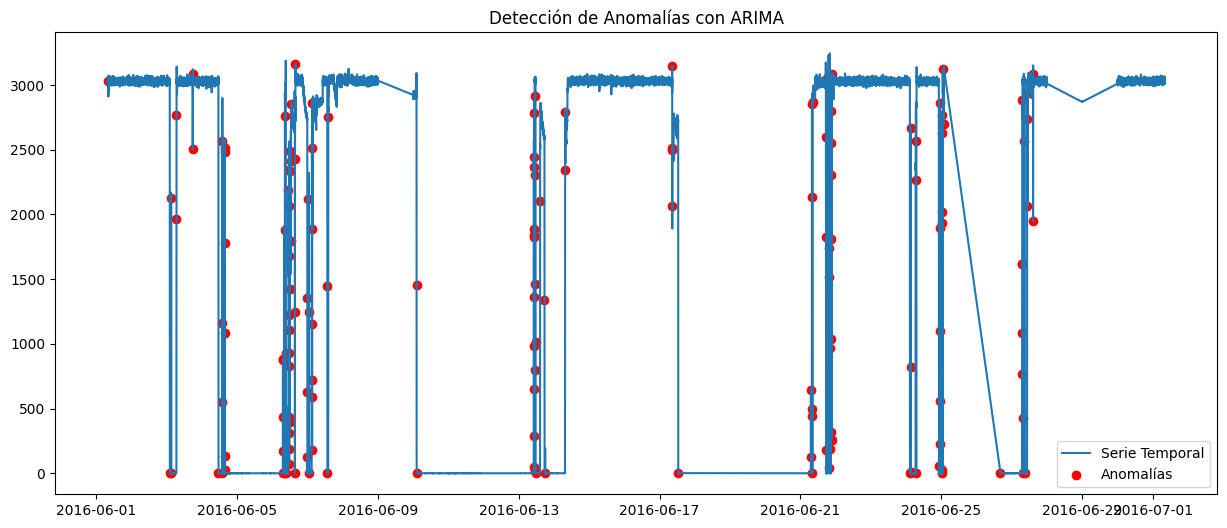

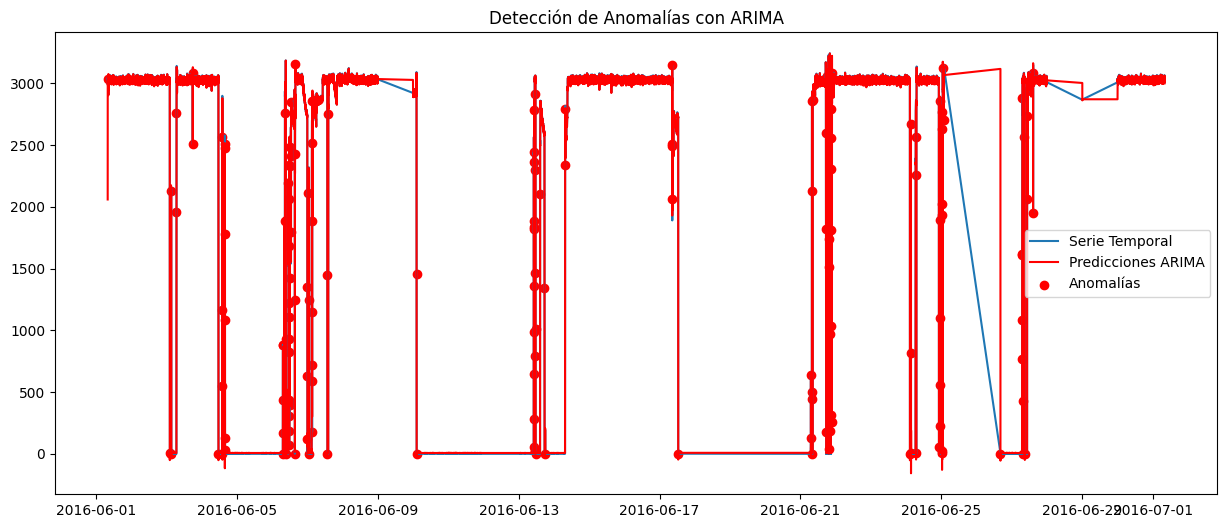

In [29]:

# Ajustar el modelo ARIMA
model = ARIMA(series, order=(5, 0, 0))  # (p, d, q) 
#model = ARIMA(series, order=(5, 0, 0))  # (p, d, q) 

# p: número de términos autorregresivos, numero de observaciones pasadas del modelo
# d: número de diferencias no estacionales para hacer la serie temporal estacionaria
# q: número de términos de media móvil, numero de errores pasados que se deben corregir
model_fit = model.fit()

# Realizar predicciones
predictions = model_fit.predict(start=0, end=len(series)-1, dynamic=False)

# Calcular los residuos (errores)
residuals = series - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3* np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
#plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

##### d. Pc_OIT_24Real[000]: Humedad Actual

Probando si es estacionario o no
- Si lo es d=0
- Si no lo es d=1 o +

In [30]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal: secuencia de datos, en mediciones sucesivas hechas a intervalos de tiempo.
series = df.set_index('Datetime')['Pc_OIT_24Real[000]']

# Verificar si la serie es estacionaria: si la media y la varianza (propiedades estadisticas) son constantes en el tiempo. Una serie estacionaria no tiene tendencias ni estacionalidades que cambien con el tiempo.
result = adfuller(series)
print('ADF Statistic:', result[0]) # Prueba Dickey Fuller aumentada: verifica si una serie temporal es o no estacionaria
print('p-value:', result[1]) # Si es menor que 0.05, la serie temporal es estacionaria, y a reves

# Si la serie no es estacionaria (p-value > 0.05), diferenciarla
#verifica si serie temporal es estacionaria y sino lo es se aplica una trsnformacion para hacerla estacionaria
# pues arima funciona con suposicion que sus series son estacionarias
if result[1] > 0.05:
    series = series.diff().dropna() #calcula la diferencia entre un valor y el anterior y elimina los valores nulos de la diferenciacion


C:\Users\josef\AppData\Local\Temp\ipykernel_492\141152366.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


ADF Statistic: -8.732673592462271
p-value: 3.160580616553433e-14


Ver valores de p y q
- Con graficos ACF y PACF
- ACF: muestra correlacion entre la serie y sus retardos
- PACF: muestra correlacion entre la serie y sus retardos, eliminado la influencia de los retardos intermedios. 

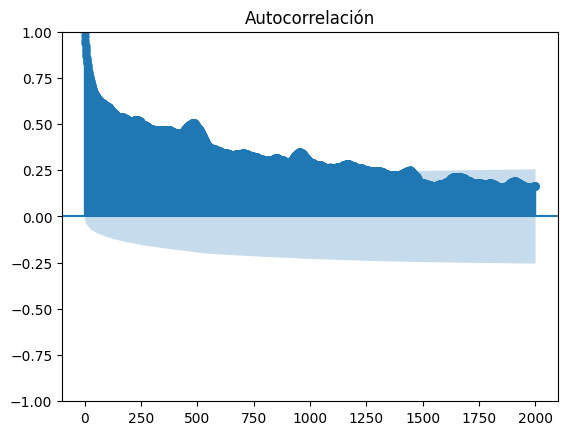

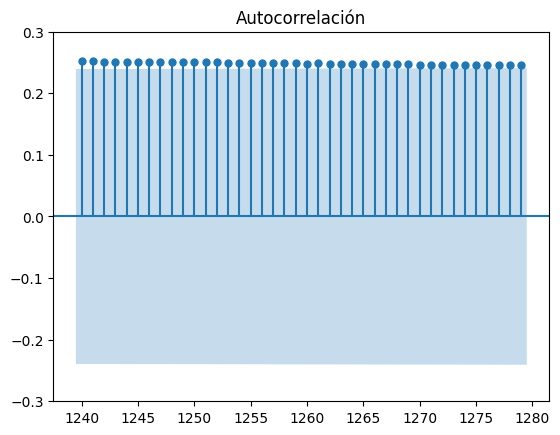

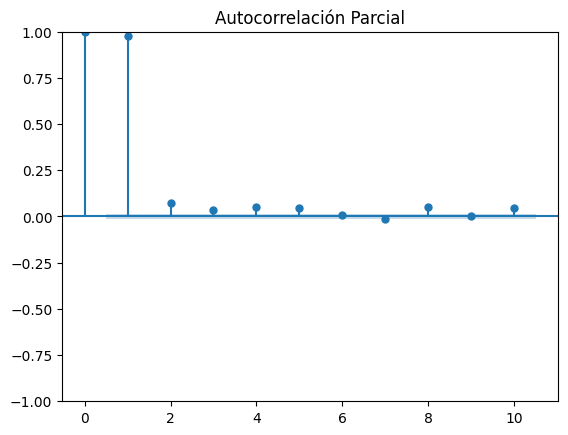

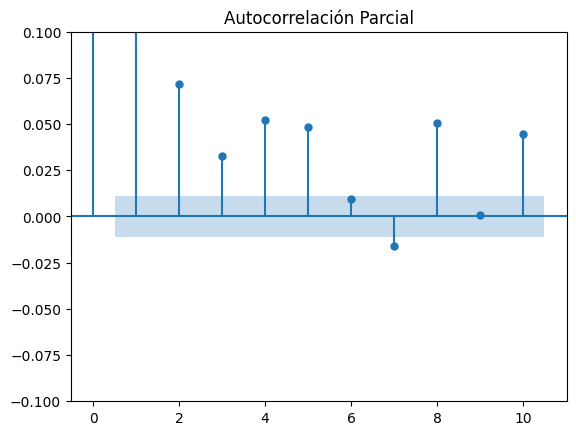

In [36]:
# Gráfico de autocorrelación
plot_acf(series, lags=2000)
plt.title('Autocorrelación')
plt.show()
# Gráfico de autocorrelación
plot_acf(series, lags=range(1240,1280))
plt.title('Autocorrelación')
plt.ylim(-0.3,0.3)
plt.show()

# Gráfico de autocorrelación parcial
plot_pacf(series, lags=10)
plt.title('Autocorrelación Parcial')
plt.show()
# Gráfico de autocorrelación parcial
plot_pacf(series, lags=10)
plt.title('Autocorrelación Parcial')
plt.ylim(-0.1,0.1)
plt.show()

- p= 1259
- d= 0
- q= 5

c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Cantidad de anomalías detectadas: 430
Anomalías detectadas:
Datetime
2016-06-01 08:00:00    1.242098
2016-06-01 08:32:00   -1.818034
2016-06-01 08:35:00   -0.908675
2016-06-01 08:38:00    2.116837
2016-06-01 08:40:00   -1.485204
                         ...   
2016-07-01 05:43:00    1.452457
2016-07-01 06:33:00   -1.242247
2016-07-01 07:35:00    0.661401
2016-07-01 07:36:00   -0.696385
2016-07-01 07:49:00    1.825992
Length: 430, dtype: float64


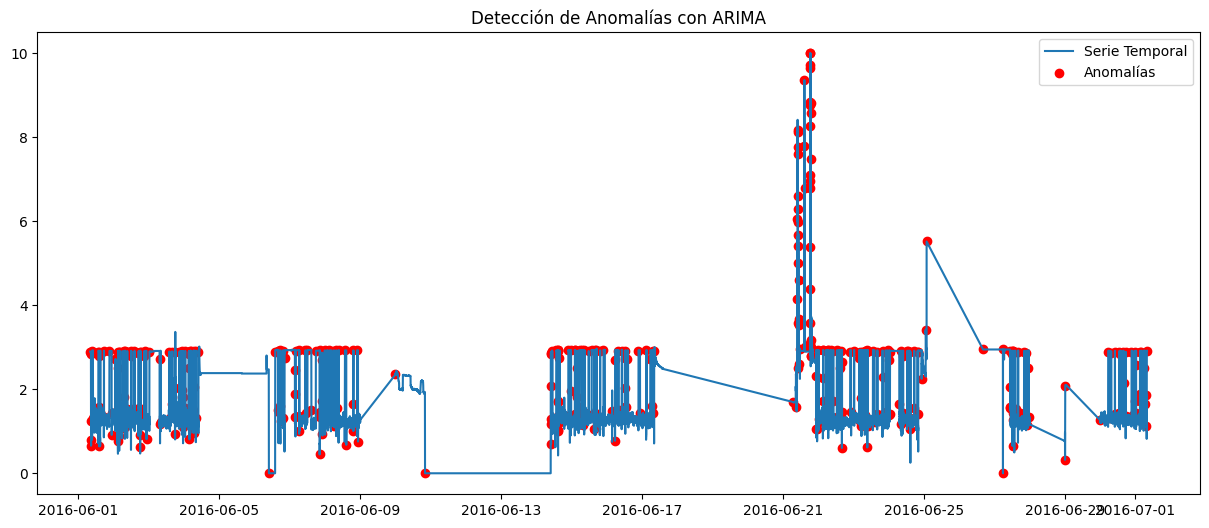

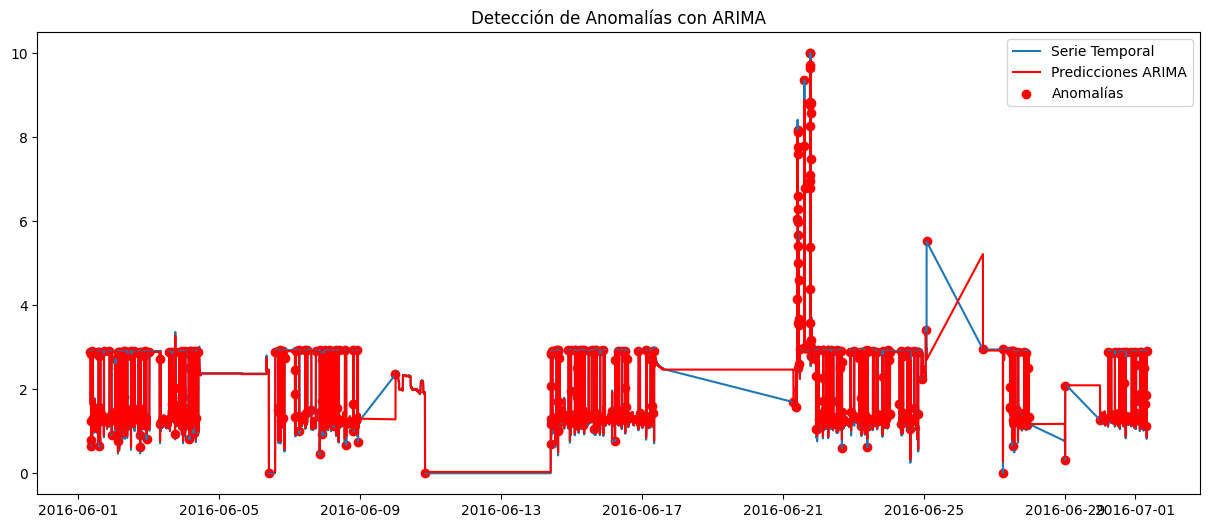

In [37]:

# Ajustar el modelo ARIMA
model = ARIMA(series, order=(5, 0, 0))  # (p, d, q) 
#model = ARIMA(series, order=(1259, 0, 5))  # (p, d, q) 

# p: número de términos autorregresivos, numero de observaciones pasadas del modelo
# d: número de diferencias no estacionales para hacer la serie temporal estacionaria
# q: número de términos de media móvil, numero de errores pasados que se deben corregir
model_fit = model.fit()

# Realizar predicciones
predictions = model_fit.predict(start=0, end=len(series)-1, dynamic=False)

# Calcular los residuos (errores)
residuals = series - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3* np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
#plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series, label='Serie Temporal')
plt.plot(predictions, color='red', label='Predicciones ARIMA')
plt.scatter(anomalies.index, series[anomalies.index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con ARIMA')
plt.show()

### LSTM

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

##### a. Pc_OIT_24Real[004]: Velocidad Maestra Freidor

C:\Users\josef\AppData\Local\Temp\ipykernel_492\2405071960.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Epoch 1/20
674/674 [==============================] - 6s 7ms/step - loss: 6.5326e-04 - val_loss: 2.1556e-06
Epoch 2/20
674/674 [==============================] - 5s 8ms/step - loss: 3.4783e-04 - val_loss: 2.3094e-05
Epoch 3/20
674/674 [==============================] - 6s 9ms/step - loss: 3.1556e-04 - val_loss: 9.8905e-06
Epoch 4/20
674/674 [==============================] - 4s 6ms/step - loss: 3.0568e-04 - val_loss: 1.3903e-05
Epoch 5/20
674/674 [==============================] - 4s 7ms/step - loss: 2.9635e-04 - val_loss: 1.3667e-07
Epoch 6/20
674/674 [==============================] - 4s 6ms/step - loss: 2.8944e-04 - val_loss: 3.9524e-07
Epoch 7/20
674/674 [==============================] - 4s 6ms/step - loss: 2.8866e-04 - val_loss: 1.0276e-05
Epoch 8/20
674/674 [==============================] - 4s 6ms/step - loss: 2.8086e-04 - val_loss: 2.7517e-06
Epoch 9/20
674/674 [==============================] - 4s 6ms/step - loss: 2.7513e-04 - val_loss: 3.4235e-06
Epoch 10/20
674/674 [=======

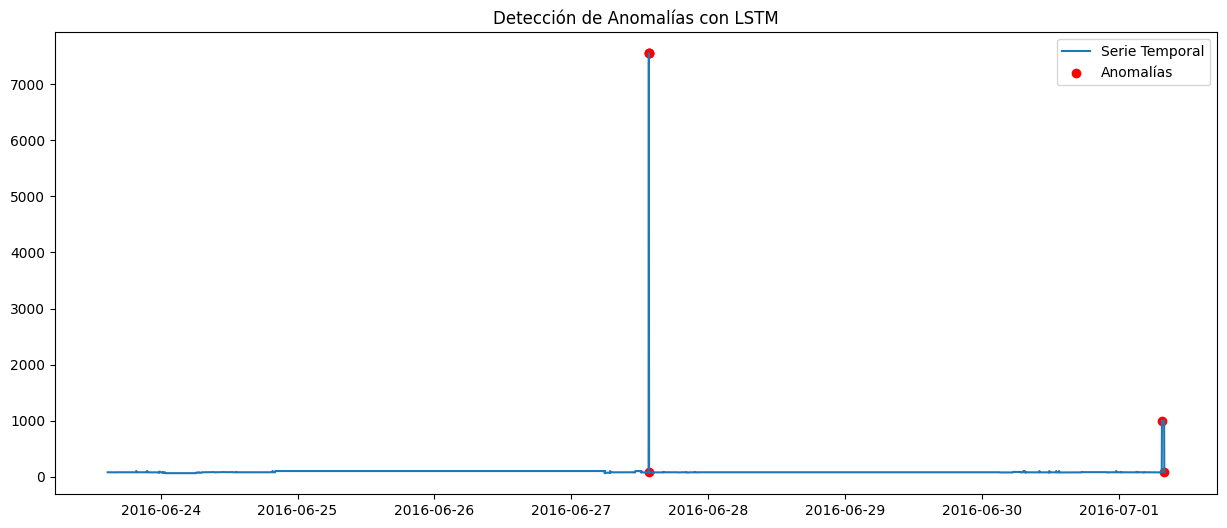

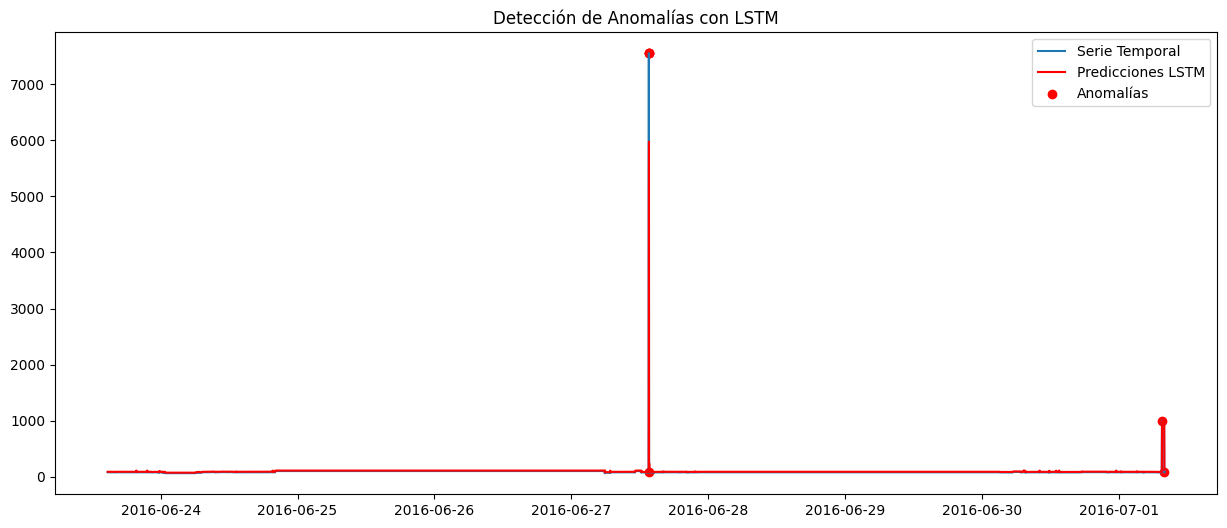

In [43]:
# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal
series = df.set_index('Datetime')['Pc_OIT_24Real[004]']

# Preprocesar los datos
scaler = MinMaxScaler(feature_range=(0, 1)) #escala los datos entre 0 y 1
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1)) #transforma los datos en un array de una sola columna

# Crear secuencias de entrada y salida
def create_sequences(data, seq_length): #crea secuencias de datos de entrada y salida
    X, y = [], [] #X=datos de entrada, y=datos de salida
    for i in range(len(data) - seq_length): #recorre los datos
        X.append(data[i:i + seq_length]) #agrega los datos de entrada 
        y.append(data[i + seq_length]) #agrega los datos de salida
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(series_scaled, seq_length) #crea las secuencias de entrada y salida

# Dividir en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:] #separar los datos de entrada en entrenamiento y prueba
y_train, y_test = y[:train_size], y[train_size:] #separar los datos de salida en entrenamiento y prueba

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1))) #agrega una capa LSTM con 50 neuronas y activacion relu
model.add(Dense(1)) 
model.compile(optimizer='adam', loss='mse') 
# RELU: Rectified Linear Unit, es una funcion de activacion que se usa en redes neuronales
# MSE: Mean Squared Error, es una funcion de perdida que se usa para problemas de regresion
# Adam: es un optimizador que se usa para ajustar los pesos de la red neuronal

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Realizar predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) #transforma los datos a su escala original
y_test = scaler.inverse_transform(y_test) #transforma los datos a su escala original

# Calcular los residuos (errores)
residuals = y_test - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3 * np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
anomalies_index = np.where(np.abs(residuals) > threshold)[0]

print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.plot(series.index[-len(y_test):], predictions, color='red', label='Predicciones LSTM')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()


##### b. Pc_OIT_24Real[001]: Nivel Aceite Actual

C:\Users\josef\AppData\Local\Temp\ipykernel_492\2593483105.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Epoch 1/20
674/674 [==============================] - 5s 5ms/step - loss: 0.0145 - val_loss: 5.4742e-05
Epoch 2/20
674/674 [==============================] - 4s 6ms/step - loss: 6.5877e-04 - val_loss: 1.0224e-04
Epoch 3/20
674/674 [==============================] - 4s 6ms/step - loss: 5.6863e-04 - val_loss: 1.7509e-04
Epoch 4/20
674/674 [==============================] - 4s 6ms/step - loss: 4.7810e-04 - val_loss: 3.8995e-05
Epoch 5/20
674/674 [==============================] - 4s 6ms/step - loss: 4.2372e-04 - val_loss: 4.3562e-05
Epoch 6/20
674/674 [==============================] - 4s 6ms/step - loss: 3.5091e-04 - val_loss: 6.6028e-05
Epoch 7/20
674/674 [==============================] - 4s 6ms/step - loss: 2.8840e-04 - val_loss: 3.0275e-05
Epoch 8/20
674/674 [==============================] - 5s 7ms/step - loss: 2.3703e-04 - val_loss: 3.5596e-05
Epoch 9/20
674/674 [==============================] - 4s 6ms/step - loss: 1.9736e-04 - val_loss: 2.5207e-05
Epoch 10/20
674/674 [===========

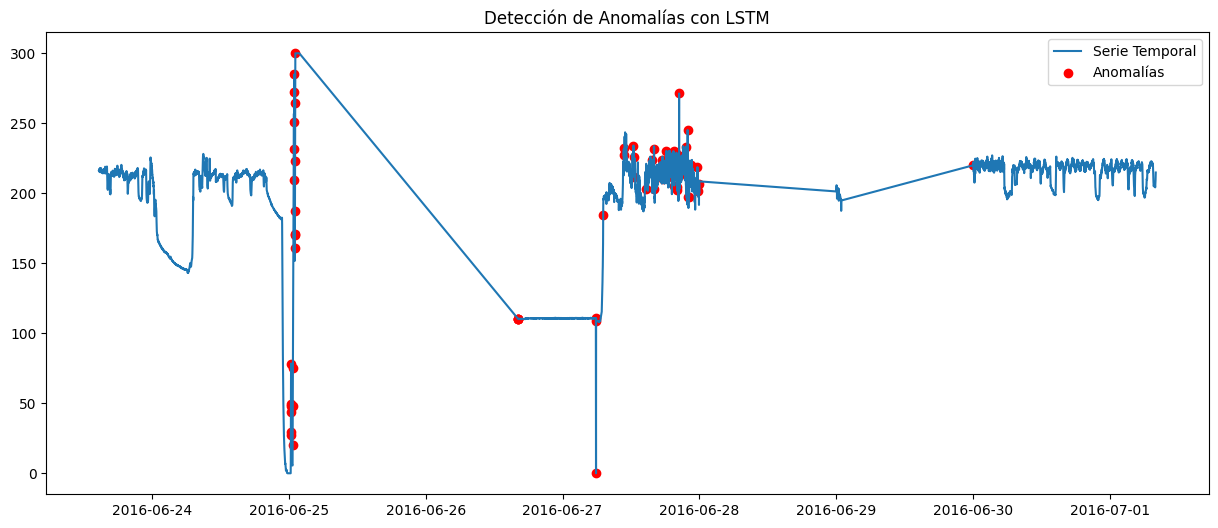

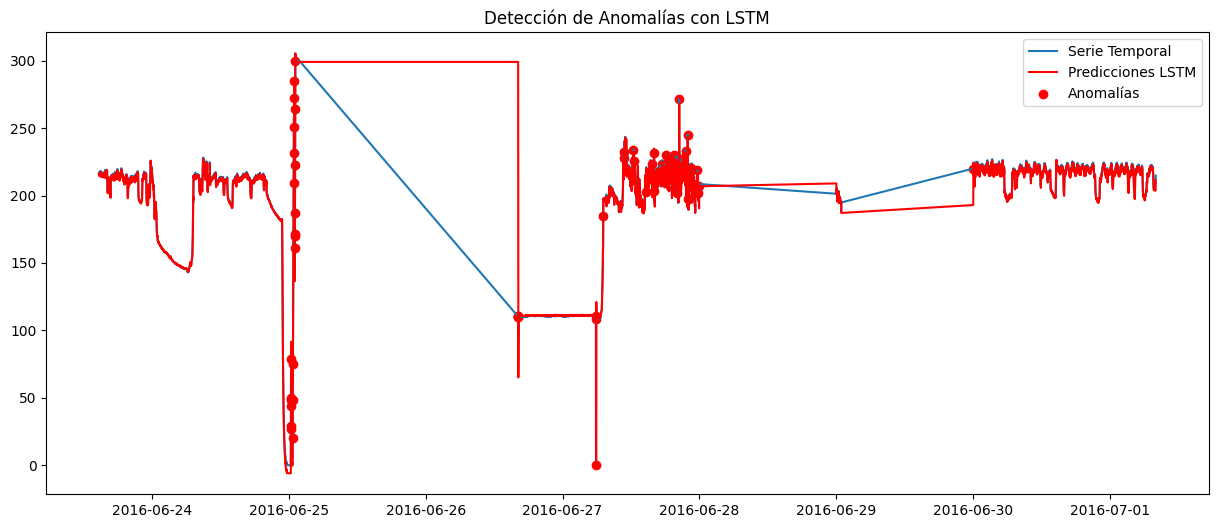

In [44]:


# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal
series = df.set_index('Datetime')['Pc_OIT_24Real[001]']

# Preprocesar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1))

# Crear secuencias de entrada y salida
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(series_scaled, seq_length)

# Dividir en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Realizar predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Calcular los residuos (errores)
residuals = y_test - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3 * np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
anomalies_index = np.where(np.abs(residuals) > threshold)[0]

print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.plot(series.index[-len(y_test):], predictions, color='red', label='Predicciones LSTM')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

##### c. FT1501.Value: Sensor Flujo Actual Aceite

C:\Users\josef\AppData\Local\Temp\ipykernel_492\2350494411.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Epoch 1/20
674/674 [==============================] - 6s 7ms/step - loss: 0.0226 - val_loss: 4.4982e-04
Epoch 2/20
674/674 [==============================] - 17s 25ms/step - loss: 0.0021 - val_loss: 1.7209e-04
Epoch 3/20
674/674 [==============================] - 21s 32ms/step - loss: 0.0016 - val_loss: 3.5200e-05
Epoch 4/20
674/674 [==============================] - 18s 27ms/step - loss: 0.0014 - val_loss: 6.1433e-05
Epoch 5/20
674/674 [==============================] - 14s 21ms/step - loss: 0.0014 - val_loss: 3.0004e-05
Epoch 6/20
674/674 [==============================] - 16s 23ms/step - loss: 0.0013 - val_loss: 4.4120e-05
Epoch 7/20
674/674 [==============================] - 20s 30ms/step - loss: 0.0013 - val_loss: 4.1287e-04
Epoch 8/20
674/674 [==============================] - 18s 26ms/step - loss: 0.0013 - val_loss: 4.9728e-05
Epoch 9/20
674/674 [==============================] - 21s 31ms/step - loss: 0.0013 - val_loss: 3.5707e-05
Epoch 10/20
674/674 [===========================

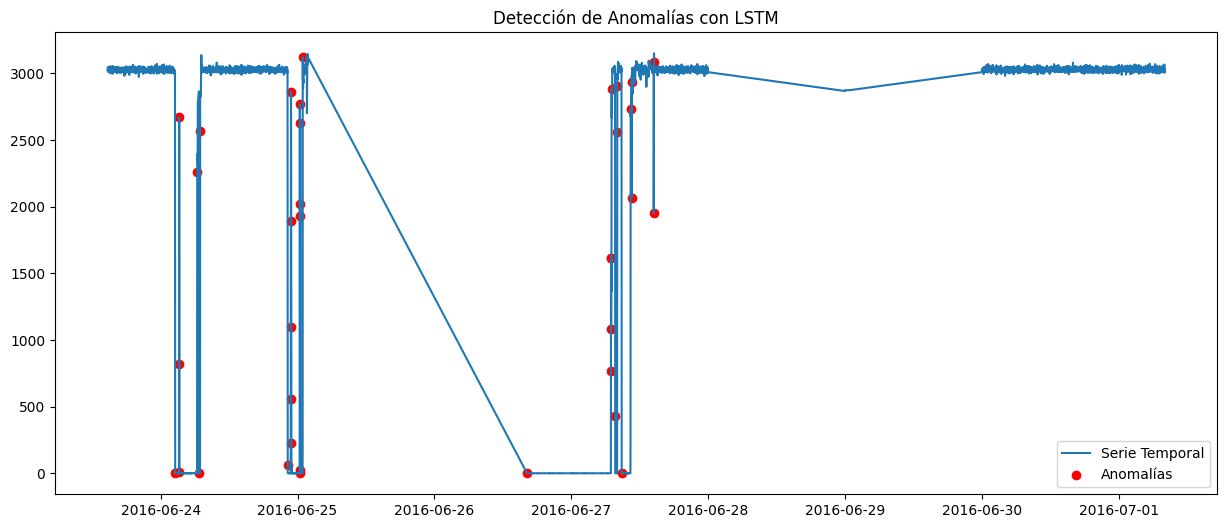

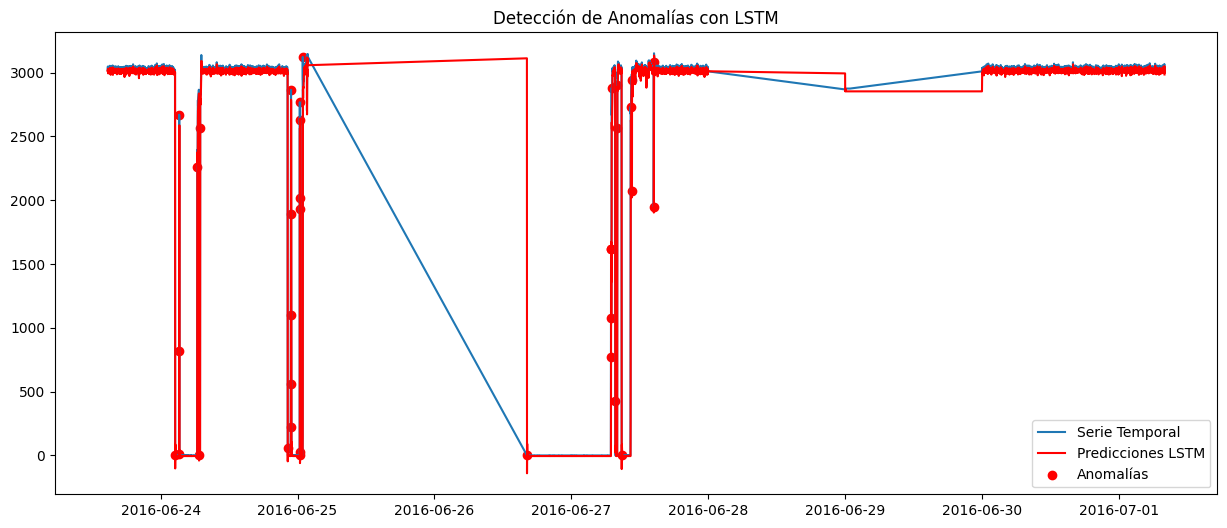

In [46]:


# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal
series = df.set_index('Datetime')['FT1501.Value']

# Preprocesar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1))

# Crear secuencias de entrada y salida
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(series_scaled, seq_length)

# Dividir en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Realizar predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Calcular los residuos (errores)
residuals = y_test - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3 * np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
anomalies_index = np.where(np.abs(residuals) > threshold)[0]

print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()
plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.plot(series.index[-len(y_test):], predictions, color='red', label='Predicciones LSTM')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

##### d. PC_OIT_24Real[000]: Humedad Actual

C:\Users\josef\AppData\Local\Temp\ipykernel_492\3989703686.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Epoch 1/20
674/674 [==============================] - 6s 6ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 2/20
674/674 [==============================] - 4s 6ms/step - loss: 7.3919e-04 - val_loss: 8.1777e-04
Epoch 3/20
674/674 [==============================] - 4s 6ms/step - loss: 6.4567e-04 - val_loss: 7.2234e-04
Epoch 4/20
674/674 [==============================] - 4s 5ms/step - loss: 5.7422e-04 - val_loss: 8.1664e-04
Epoch 5/20
674/674 [==============================] - 4s 5ms/step - loss: 5.5098e-04 - val_loss: 6.3111e-04
Epoch 6/20
674/674 [==============================] - 4s 6ms/step - loss: 5.2695e-04 - val_loss: 5.8271e-04
Epoch 7/20
674/674 [==============================] - 9s 14ms/step - loss: 5.1509e-04 - val_loss: 5.9373e-04
Epoch 8/20
674/674 [==============================] - 9s 14ms/step - loss: 4.9851e-04 - val_loss: 6.1100e-04
Epoch 9/20
674/674 [==============================] - 10s 15ms/step - loss: 4.9670e-04 - val_loss: 5.8050e-04
Epoch 10/20
674/674 [===========

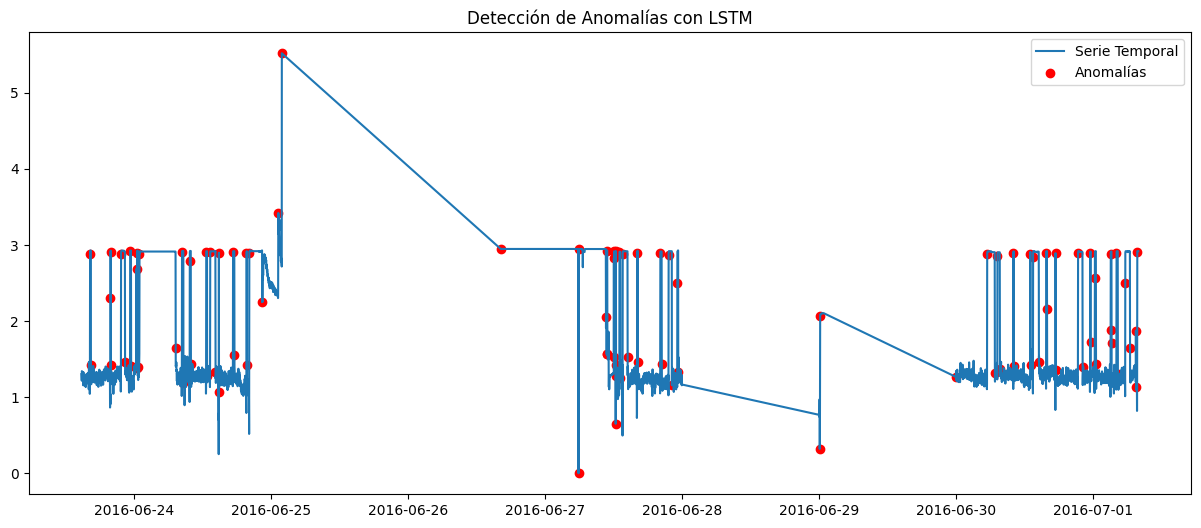

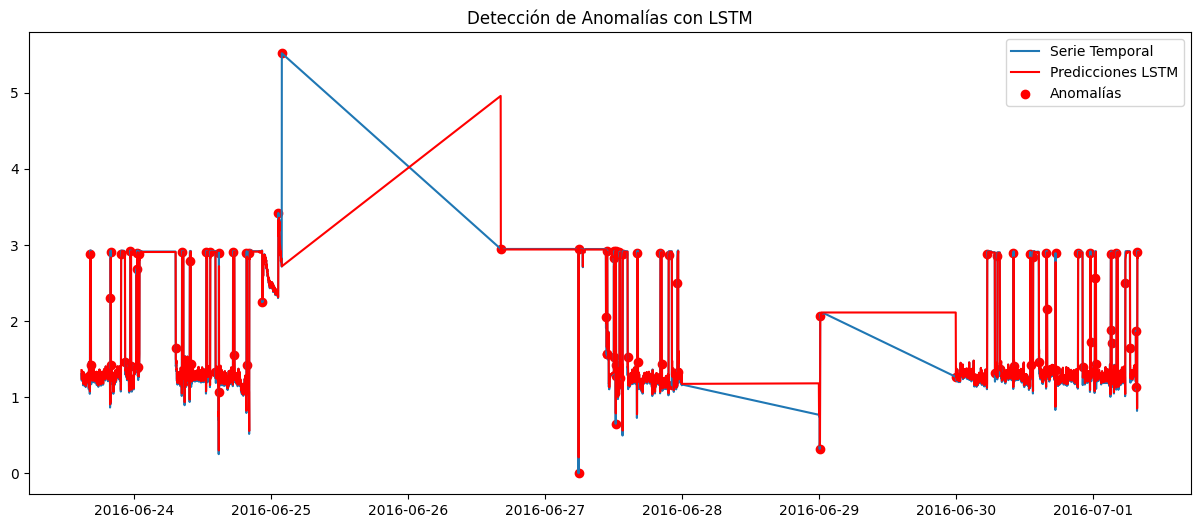

In [48]:


# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar la columna de interés para la serie temporal
series = df.set_index('Datetime')['Pc_OIT_24Real[000]']

# Preprocesar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1))

# Crear secuencias de entrada y salida
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(series_scaled, seq_length)

# Dividir en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Realizar predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Calcular los residuos (errores)
residuals = y_test - predictions

# Calcular el umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
threshold = 3 * np.std(residuals)

# Detectar anomalías
anomalies = residuals[np.abs(residuals) > threshold]
anomalies_index = np.where(np.abs(residuals) > threshold)[0]

print(f'Cantidad de anomalías detectadas: {len(anomalies)}')

# Mostrar las anomalías
print('Anomalías detectadas:')
print(anomalies)

# Graficar la serie temporal y las anomalías
plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(series.index[-len(y_test):], y_test, label='Serie Temporal')
plt.plot(series.index[-len(y_test):], predictions, color='red', label='Predicciones LSTM')
plt.scatter(series.index[-len(y_test):][anomalies_index], y_test[anomalies_index], color='red', label='Anomalías')
plt.legend()
plt.title('Detección de Anomalías con LSTM')
plt.show()

## 2. FILE1AA_MODIFICADO

- FILE1AA_MODIFICADO: humedad, master speed, nivel banda tolva, flujo aceite, temp salida intercambiador, deltaTpid


Lo mismo de arriba pero con cambiando el CSV y las variables correspondientes.